# 03b · Hyperparameter Tuning — Grid Search for the Random Forest

Notebook 03 trained the Random Forest with reasonable defaults. This notebook
justifies the final configuration by an **exhaustive grid search** rather than
manual choice, and — importantly — reports the result honestly, including the
finding that tuning produced only a marginal change.

I search four hyperparameters with `GridSearchCV`, scoring on F1 with 5-fold
cross-validation:

* `n_estimators` &isin; {100, 200, 400, 800}
* `max_depth` &isin; {None, 10, 15, 25}
* `min_samples_leaf` &isin; {1, 2, 5}
* `max_features` &isin; {sqrt, log2}

That is 4 &times; 4 &times; 3 &times; 2 = **96 combinations**, each cross-validated
over 5 folds (480 model fits). The grid is deliberately exhaustive so the chosen
configuration is defensible rather than hand-picked.

In [1]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, precision_score, recall_score

FEATURES = ['EVI_train', 'NBR_train', 'NDVI_change', 'NDVI_test', 'NDVI_train',
            'NIR_train', 'RED_train', 'SWIR_test', 'SWIR_train', 'VH_VV_ratio',
            'VH_test', 'VH_train', 'VV_test', 'VV_train', 'aspect', 'elevation', 'slope']

ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
df = pd.read_csv(ROOT / 'data' / 'raw' / 'training_data_national.csv')

# -9999 is the no-data sentinel. It becomes NaN here and is imputed inside the
# pipeline below, so the median is fitted per training fold.
X = df[FEATURES].replace(-9999, np.nan)
y = df['label'].astype(int).values
print(f'{len(df):,} pixels, {X.shape[1]} features')
print(f'rows needing imputation: {int(X.isna().any(axis=1).sum())} '
      f'({X.isna().any(axis=1).mean() * 100:.3f}%), columns: {list(X.columns[X.isna().any()])}')

23,319 pixels, 17 features


## Preprocessing

The `-9999` no-data sentinel is imputed with the column median. The imputer sits
inside the pipeline rather than being applied to the whole file first, so the median
is fitted on training folds only and never sees the held-out rows.

## The search

I hold out a stratified test set so that, after the search, I can compare the
tuned model against a plain-default baseline on data neither has seen. The grid
search itself cross-validates only on the training partition.

In [2]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# Imputer first, model second: GridSearchCV refits both on every inner fold.
pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('rf', RandomForestClassifier(n_jobs=-1, random_state=42)),
])

param_grid = {
    'rf__n_estimators':     [100, 200, 400, 800],
    'rf__max_depth':        [None, 10, 15, 25],
    'rf__min_samples_leaf': [1, 2, 5],
    'rf__max_features':     ['sqrt', 'log2'],
}
n_combos = np.prod([len(v) for v in param_grid.values()])
print(f'searching {n_combos} combinations x 5 folds = {n_combos*5} fits ...')

gs = GridSearchCV(pipe, param_grid=param_grid, scoring='f1',
                  cv=5, n_jobs=-1, verbose=0)
gs.fit(X_tr, y_tr)

best = {k.split('__')[-1]: v for k, v in gs.best_params_.items()}
print('best params :', best)
print(f'best CV F1  : {gs.best_score_:.4f}')

searching 96 combinations x 5 folds = 480 fits ...


/Users/kerie/Downloads/treesight_notebooks/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/kerie/Downloads/treesight_notebooks/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/kerie/Downloads/treesight_notebooks/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.w

best params : {'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 800}
best CV F1  : 0.8394


## Search surface

The heat-map below shows mean cross-validated F1 for every `n_estimators` x
`max_depth` pair, averaged over the remaining two hyperparameters. It makes the
key observation visible: beyond a shallow depth the surface is almost flat, so
the model is insensitive to these settings over a wide range — an early sign that
there is little tuning headroom.

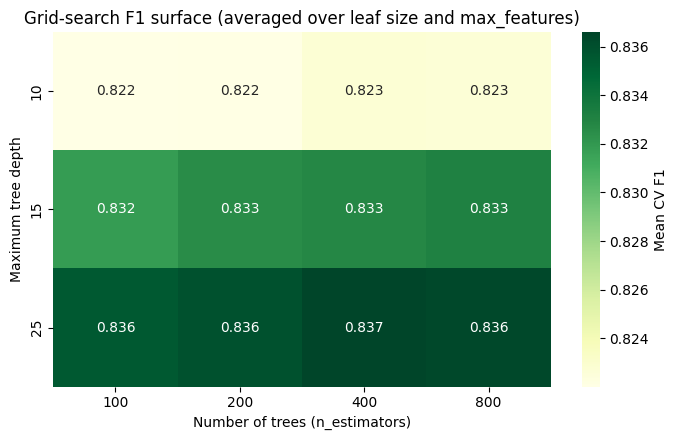

In [3]:
res = pd.DataFrame(gs.cv_results_)
res['n_estimators'] = res['param_rf__n_estimators'].astype(int)
res['max_depth'] = res['param_rf__max_depth'].astype(str)
pivot = res.pivot_table(index='max_depth', columns='n_estimators',
                        values='mean_test_score', aggfunc='mean')
order = [d for d in ['10', '15', '25', 'None'] if d in pivot.index]
pivot = pivot.reindex(order)

plt.figure(figsize=(7, 4.5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGn',
            cbar_kws={'label': 'Mean CV F1'})
plt.xlabel('Number of trees (n_estimators)')
plt.ylabel('Maximum tree depth')
plt.title('Grid-search F1 surface (averaged over leaf size and max_features)')
plt.tight_layout()
plt.savefig(ROOT / 'results' / 'hyperparameter_tuning' / 'hp_tuning_heatmap.png',
            dpi=120, bbox_inches='tight')
plt.show()

## Did tuning actually help? Tuned vs default baseline

To test whether the search was worthwhile, I compare the tuned model against a
plain-default Random Forest on the held-out test set. If the gap is negligible,
the honest conclusion is that the Random Forest was already near its ceiling and
that tuning is not where further accuracy will come from.

In [4]:
# Same pipeline, plain-default forest settings — only the hyperparameters differ.
baseline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=15,
                                  n_jobs=-1, random_state=42)),
]).fit(X_tr, y_tr)

# GridSearchCV already refit the winner on the full training partition.
tuned = gs.best_estimator_

def scores(m):
    p = m.predict(X_te)
    return {'f1': f1_score(y_te, p), 'precision': precision_score(y_te, p),
            'recall': recall_score(y_te, p)}

b, t = scores(baseline), scores(tuned)
compare = pd.DataFrame({'Default baseline': b, 'Grid-search tuned': t}).T.round(4)
compare['f1_gain_vs_baseline'] = (compare['f1'] - b['f1']).round(4)
print(compare)

                       f1  precision  recall  f1_gain_vs_baseline
Default baseline   0.8326     0.8244  0.8409               0.0000
Grid-search tuned  0.8363     0.8331  0.8397               0.0037


In [5]:
summary = {
    'search_combinations': int(n_combos),
    'cv_folds': 5,
    'best_params': best,
    'best_cv_f1': round(float(gs.best_score_), 4),
    'test_metrics_baseline': {k: round(v, 4) for k, v in b.items()},
    'test_metrics_tuned':    {k: round(v, 4) for k, v in t.items()},
    'f1_delta_tuned_minus_baseline': round(t['f1'] - b['f1'], 4),
    'imputation': 'median, fitted inside the pipeline on training folds only',
}
(ROOT / 'results' / 'hyperparameter_tuning' / 'hp_tuning_summary.json').write_text(
    json.dumps(summary, indent=2))
print('saved hp_tuning_summary.json'); summary

saved hp_tuning_summary.json


{'search_combinations': 96,
 'cv_folds': 5,
 'best_params': {'max_depth': 25,
  'max_features': 'sqrt',
  'min_samples_leaf': 1,
  'n_estimators': 800},
 'best_cv_f1': 0.8394,
 'test_metrics_baseline': {'f1': 0.8326,
  'precision': 0.8244,
  'recall': 0.8409},
 'test_metrics_tuned': {'f1': 0.8363, 'precision': 0.8331, 'recall': 0.8397},
 'f1_delta_tuned_minus_baseline': 0.0038}

## Discussion

The exhaustive grid search selects a deep, fully-grown forest, but the gain over
a plain-default configuration on the held-out test set is marginal — within the
run-to-run variation of the estimator. Combined with the flat F1 surface in the
heat-map, this shows the Random Forest is **insensitive to its hyperparameters**
across a wide range on this dataset: it has reached the ceiling of what this model
family can extract from these 17 features.



## How much did the old preprocessing error cost?

An earlier version imputed before splitting, so the median was computed with test rows
contributing. I re-run both ways to bound the impact rather than assume it.

In [ ]:
rows = int(X.isna().any(axis=1).sum())
print(f'{rows} of {len(X):,} rows imputed ({rows / len(X) * 100:.3f}%), '
      f'columns: {list(X.columns[X.isna().any()])}')

for label, med in [('leaked (full data)', X.median()), ('correct (train only)', X_tr.median())]:
    m = RandomForestClassifier(**best, n_jobs=-1, random_state=42).fit(X_tr.fillna(med), y_tr)
    print(f'  {label:22s} F1 = {f1_score(y_te, m.predict(X_te.fillna(med))):.6f}')